In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import InfoGlobe
from InfoGlobe.metrics import fisher_rao_dis_matrix
from InfoGlobe.utils import get_knn


/home/wangcheng/anaconda3/envs/MarkovMF/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad('../../../../../nfs/chengwang_data/ICML_data/factor_sim/adata_0.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 1500 × 200
    obs: 'cell_type'

In [4]:
adata = adata[0:10000, :].copy()

In [6]:
adata.write("../../../../../nfs/chengwang_data/ICML_data/sim_data/adata_2.h5ad")

In [15]:
adata

AnnData object with n_obs × n_vars = 10000 × 700
    obs: 'cell_type'

In [7]:
data = []
for i in range(1,11,1):
    P_ = adata.X[0:i*1000,:].copy()
    P_ = P_ / P_.sum(axis=1, keepdims=True)
    P_gd = P_.T
    data.append(P_gd)


In [10]:
data[-1].shape

(700, 10000)

In [4]:
P = adata.X
P = P / P.sum(axis=1, keepdims=True)
P_gd = P.T

<Axes: >

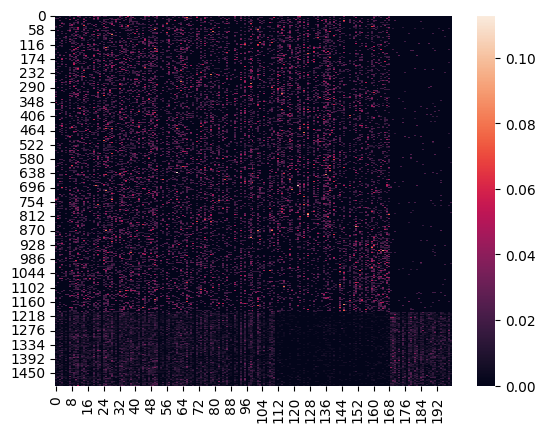

In [5]:
sns.heatmap(P)

In [6]:
n, m = P_gd.shape
k = 50

In [7]:
gb = InfoGlobe.infoglobe.GlobeEmbedding(A = [n,k], Q = [k,m], c=1)

In [20]:
import time

In [21]:
time_lis = []

In [24]:
for i in range(10):
    n, m = data[i].shape
    k = 6
    gb = InfoGlobe.infoglobe.GlobeEmbedding(A = [n,k], Q = [k,m], c=1)
    start = time.time()
    gb.fit(torch.Tensor(data[i]), max_iter=10000)
    end = time.time()
    time_lis.append(end-start)

100%|██████████| 10000/10000 [00:33<00:00, 299.56it/s]


In [9]:
gb.fit(torch.Tensor(P_gd), max_iter=20000)

  0%|          | 0/20000 [00:00<?, ?it/s]/home/wangcheng/projects/InfoGlobe_ICML/InfoGlobe/infoglobe.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/wangcheng/projects/InfoGlobe_ICML/InfoGlobe/infoglobe.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 20000/20000 [00:51<00:00, 391.57it/s]


20000

In [17]:
np.sum(gb.Q.detach().cpu().numpy().T[4,:])

np.float32(1.0000001)

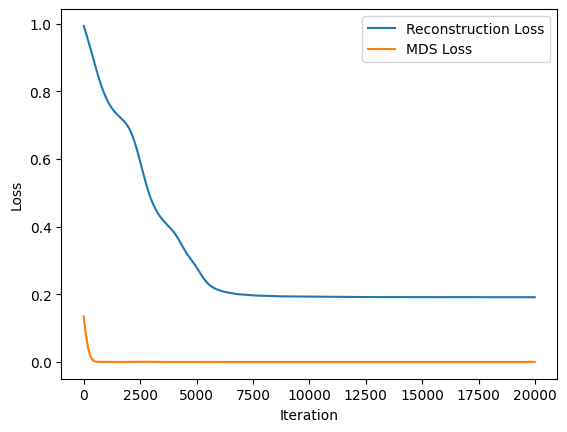

In [ ]:
x = [i*10 for i in range(len(MMF.loss1))]               

plt.plot(x, gb.loss1, label='Reconstruction Loss')        
plt.plot(x, gb.loss2, label='MDS Loss')                   

plt.xlabel("Iteration")
plt.ylabel("Loss")         
plt.legend()
plt.show()      

In [26]:
data[-1].shape

(700, 10000)

In [25]:
time_lis

[29.037420988082886,
 30.93372631072998,
 31.35342001914978,
 31.626575708389282,
 31.937070608139038,
 32.071882247924805,
 32.381155252456665,
 32.803471326828,
 33.152061223983765,
 33.41136431694031]

In [16]:
time_ig = [29, 37, 46.35342001914978, 68,77, 110.31, 120.51, 155.51, 179.01,210]
time_scvi = [30.93, 55.77, 79.24, 89.64, 110.47, 133.53, 158.90, 190.72, 215.42, 241.37]
time_scphere = [41.52, 85.10, 130.77, 179.36, 227.91, 261.31, 306.93, 358.27, 400.33, 439.53]

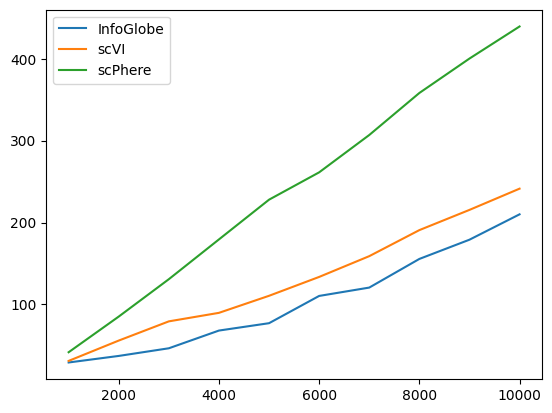

In [17]:
x = [1000,2000,3000,4000, 5000,6000, 7000, 8000, 9000,10000]

plt.plot(x, time_ig, label='InfoGlobe')
plt.plot(x, time_scvi, label='scVI')
plt.plot(x, time_scphere, label='scPhere')
plt.legend()
plt.show()

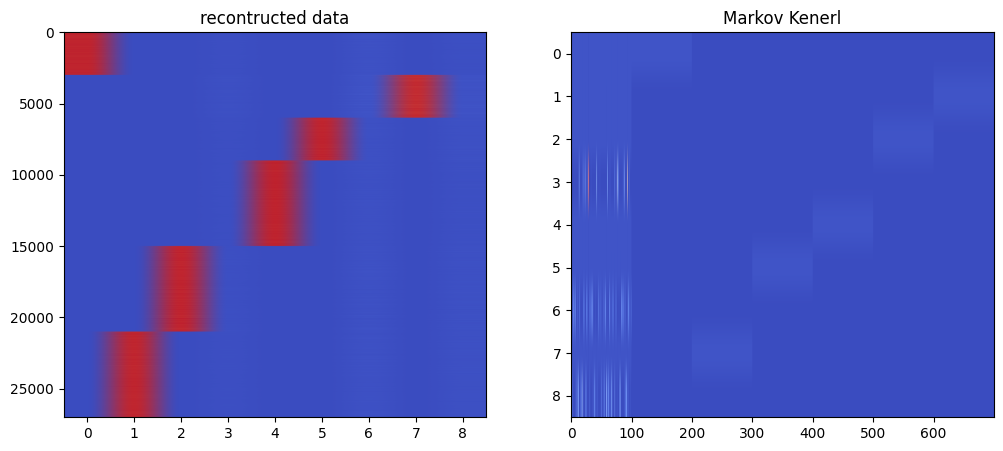

In [ ]:
plt.figure(figsize=(12, 5))

# plt.subplot(1, 3, 1)
# plt.title("raw Data")
# plt.imshow(Q.T, aspect='auto', cmap='coolwarm')

plt.subplot(1, 2, 1)
plt.title("recontructed data")
plt.imshow(gb.Q.detach().cpu().numpy().T, aspect='auto', cmap='coolwarm')

plt.subplot(1, 2, 2)
plt.title("Markov Kenerl")
plt.imshow(gb.A.detach().cpu().numpy().T, aspect='auto', cmap='coolwarm')


plt.show()